***Mo hinh CNN***

In [1]:
# ============================
# B22DCCN476 - Đỗ Ngọc Lâm 
# ============================

import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn_model(input_shape=(64, 64, 3), num_classes=10):
    model = models.Sequential(name="Simple_CNN")

    # --- Khối trích xuất đặc trưng ---
    # Tầng tích chập 1: học cạnh, góc, texture đơn giản
    model.add(layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu',
                            input_shape=input_shape, name="conv1"))
    model.add(layers.MaxPooling2D(pool_size=(2,2), name="pool1"))

    # Tầng tích chập 2: học đặc trưng phức tạp hơn (hình khối, bộ phận đối tượng)
    model.add(layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu',
                            name="conv2"))
    model.add(layers.MaxPooling2D(pool_size=(2,2), name="pool2"))

    # Có thể thêm 1 block nữa để sâu hơn
    model.add(layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu',
                            name="conv3"))
    model.add(layers.MaxPooling2D(pool_size=(2,2), name="pool3"))

    # --- Khối phân loại ---
    # Trải phẳng feature map thành vector
    model.add(layers.Flatten(name="flatten"))

    # Dense layer: học quan hệ giữa các đặc trưng đã trích xuất
    model.add(layers.Dense(128, activation='relu', name="fc1"))

    # Lớp đầu ra: softmax cho phân loại
    model.add(layers.Dense(num_classes, activation='softmax', name="output"))

    return model

cnn_model = build_cnn_model()
cnn_model.summary()


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Simple_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                       │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2 (Conv2D)                       │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3 (Conv2D)                       │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool3 (MaxPooling2D)                 │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 684,490 (2.61 MB)

 Trainable params: 684,490 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

***Mô hình RNN***

In [2]:
# ============================
# B22DCCN476
# ============================

import tensorflow as tf
from tensorflow.keras import layers, models

def build_rnn_model(timesteps=20, feature_dim=50, num_classes=5):
    """
    timesteps   = độ dài chuỗi (ví dụ: câu có 20 từ)
    feature_dim = số đặc trưng mỗi bước (ví dụ: embedding 50 chiều)
    """
    model = models.Sequential(name="Simple_RNN")

    # Tầng RNN cơ bản:
    # - đọc chuỗi theo thứ tự thời gian
    # - giữ một trạng thái ẩn để "nhớ ngắn hạn"
    model.add(layers.SimpleRNN(
        units=64,
        activation='tanh',
        return_sequences=False,  # chỉ lấy trạng thái cuối cùng
        input_shape=(timesteps, feature_dim),
        name="rnn_layer"
    ))

    # Dense cuối để ra dự đoán (ví dụ: phân loại cảm xúc câu)
    model.add(layers.Dense(64, activation='relu', name="fc1"))
    model.add(layers.Dense(num_classes, activation='softmax', name="output"))

    return model

rnn_model = build_rnn_model()
rnn_model.summary()


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rnn_layer (SimpleRNN)                │ (None, 64)                  │           7,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,845 (46.27 KB)

 Trainable params: 11,845 (46.27 KB)

 Non-trainable params: 0 (0.00 B)

***Mô hình LSTM***

In [3]:
# ============================
#B22DCCN476
# ============================

import tensorflow as tf
from tensorflow.keras import layers, models

def build_lstm_model(timesteps=50, feature_dim=100, num_classes=5):
    """
    timesteps   = độ dài chuỗi dài hơn (ví dụ: 50 từ)
    feature_dim = số đặc trưng tại mỗi bước (ví dụ: embedding 100 chiều)
    """
    model = models.Sequential(name="Simple_LSTM")

    # Tầng LSTM:
    # - có bộ nhớ (cell state) và các cổng (quên / ghi / xuất)
    # - giữ được thông tin dài hạn trong chuỗi
    model.add(layers.LSTM(
        units=128,
        return_sequences=False,   # lấy trạng thái cuối cùng
        input_shape=(timesteps, feature_dim),
        name="lstm_layer"
    ))

    # Dense cuối (phân loại, dự báo, v.v.)
    model.add(layers.Dense(128, activation='relu', name="fc1"))
    model.add(layers.Dense(num_classes, activation='softmax', name="output"))

    return model

lstm_model = build_lstm_model()
lstm_model.summary()


Model: "Simple_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_layer (LSTM)                    │ (None, 128)                 │         117,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 134,405 (525.02 KB)

 Trainable params: 134,405 (525.02 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Cell #1: Import & global config
# Đỗ Ngọc Lâm - B22DCCN476
# --------------------------------
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, models

# Để kết quả tái lập
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Đường dẫn file CSV thời tiết
DATA_PATH = r"C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\ktra2\DATA\weather_vietnam2\df_weather.csv"

# Các thành phố cần dự báo
CITIES = ["Hà Nội", "Đà Nẵng", "TP. Hồ Chí Minh"]

# Độ dài chuỗi đầu vào (7 ngày gần nhất)
SEQ_LEN = 7

# Cột dùng làm nhãn (giá trị cần dự báo)
TARGET_COL = "day.maxtemp_c"

# Một số hàm tiện ích sẽ viết ở cell sau
print("✅ Cell #1 OK: thư viện đã import.")


✅ Cell #1 OK: thư viện đã import.


In [5]:
# Cell #2: Load & filter cities
# Đỗ Ngọc Lâm - B22DCCN476
# -----------------------------
df = pd.read_csv(DATA_PATH)

# Chuẩn hoá tên cột cho dễ dùng
df.columns = [c.strip().replace(" ", "_") for c in df.columns]

# Ép kiểu date -> datetime, sort theo thời gian
df["date"] = pd.to_datetime(df["date"])

# Lọc chỉ 3 thành phố quan tâm
df_city = df[df["location.name"].isin(CITIES)].copy()

# Sắp xếp theo từng thành phố và ngày
df_city = df_city.sort_values(by=["location.name", "date"]).reset_index(drop=True)

print("Dữ liệu 3 thành phố:")
print(df_city[["location.name","date","day.maxtemp_c","day.mintemp_c","day.avgtemp_c",
               "day.avghumidity","day.daily_will_it_rain","day.daily_chance_of_rain"]].head(15))
print("Số dòng mỗi city:")
print(df_city["location.name"].value_counts())


Dữ liệu 3 thành phố:
   location.name       date  day.maxtemp_c  day.mintemp_c  day.avgtemp_c  \
0         Hà Nội 2024-04-21           32.2           25.4           28.4   
1         Hà Nội 2024-04-22           32.1           24.4           27.8   
2         Hà Nội 2024-04-23           29.7           25.2           26.8   
3         Hà Nội 2024-04-24           30.2           23.4           26.3   
4         Hà Nội 2024-04-25           35.8           23.8           28.3   
5         Hà Nội 2024-04-26           37.1           25.0           29.9   
6         Hà Nội 2024-04-27           42.5           25.6           32.4   
7         Hà Nội 2024-04-28           39.2           25.9           31.2   
8         Hà Nội 2024-04-29           40.0           26.0           31.7   
9         Hà Nội 2024-04-30           39.9           26.7           32.5   
10        Hà Nội 2024-05-01           29.1           24.6           27.2   
11        Hà Nội 2024-05-02           26.8           22.9          

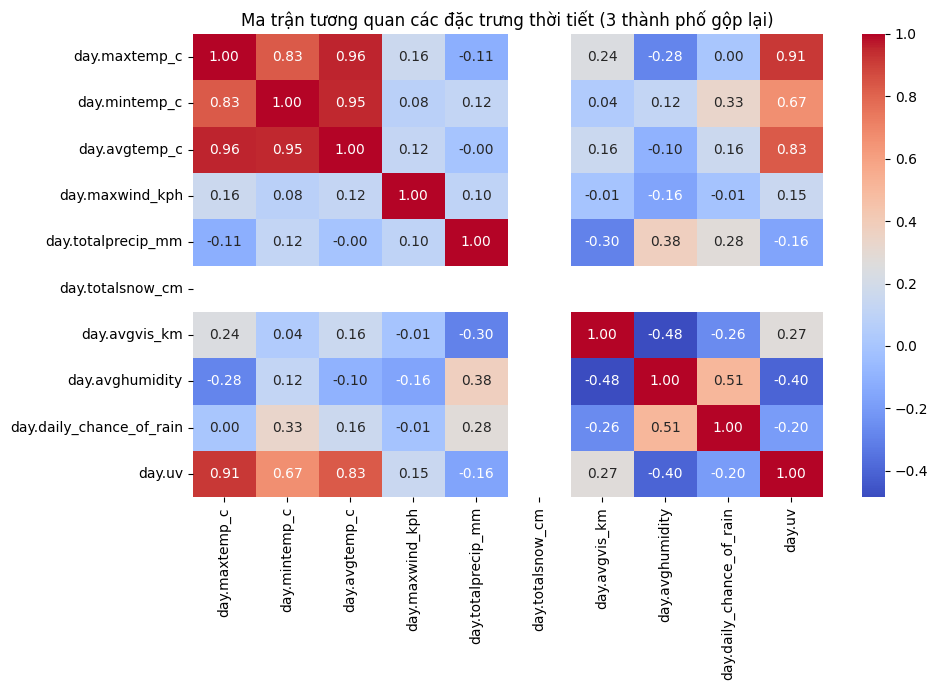

Nhận xét nhanh:
- Hệ số tương quan gần 1 hoặc -1 => liên hệ mạnh.
- Ta kỳ vọng 'day.avgtemp_c' và 'day.mintemp_c' sẽ tương quan cao với 'day.maxtemp_c'.


In [6]:
# Cell #3: Correlation matrix
# Đỗ Ngọc Lâm - B22DCCN476
# ---------------------------
import seaborn as sns

# Các feature numeric tiềm năng
num_cols = [
    "day.maxtemp_c",
    "day.mintemp_c",
    "day.avgtemp_c",
    "day.maxwind_kph",
    "day.totalprecip_mm",
    "day.totalsnow_cm",
    "day.avgvis_km",
    "day.avghumidity",
    "day.daily_chance_of_rain",
    "day.uv"
]

corr_data = df_city[num_cols].corr(method="pearson")

plt.figure(figsize=(10,7))
sns.heatmap(corr_data, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Ma trận tương quan các đặc trưng thời tiết (3 thành phố gộp lại)")
plt.tight_layout()
plt.show()

print("Nhận xét nhanh:")
print("- Hệ số tương quan gần 1 hoặc -1 => liên hệ mạnh.")
print("- Ta kỳ vọng 'day.avgtemp_c' và 'day.mintemp_c' sẽ tương quan cao với 'day.maxtemp_c'.")


In [7]:
# Cell #4: Hàm tạo dataset chuỗi thời gian
# Đỗ Ngọc Lâm - B22DCCN476
# ----------------------------------------

def build_city_sequences(df_city_single,
                         feature_cols,
                         target_col=TARGET_COL,
                         seq_len=SEQ_LEN,
                         test_ratio=0.2):
    """
    df_city_single: dataframe chỉ chứa 1 thành phố, đã sort theo date tăng dần.
    feature_cols: list tên cột feature numeric.
    target_col: cột cần dự báo (scalar).
    seq_len: số ngày quá khứ dùng để dự đoán.
    test_ratio: tỉ lệ tách test theo thời gian (cuối chuỗi).
    
    return:
      X_train, y_train, X_val, y_val, X_test, y_test, scaler
    """
    df_single = df_city_single.copy().reset_index(drop=True)

    # Chỉ giữ các cột cần thiết (features + target + date để tham khảo)
    data_feat = df_single[feature_cols].values.astype("float32")
    data_target = df_single[target_col].values.astype("float32")

    # Scale toàn bộ feature theo MinMax cho thành phố này (giữ riêng scaler cho từng city)
    scaler = MinMaxScaler()
    data_feat_scaled = scaler.fit_transform(data_feat)

    # Tạo các sample chuỗi
    X_list = []
    y_list = []

    for i in range(len(df_single) - seq_len):
        X_seq = data_feat_scaled[i:i+seq_len]              # seq_len x num_features
        y_next = data_target[i+seq_len]                    # giá trị ngày kế
        X_list.append(X_seq)
        y_list.append(y_next)

    X = np.array(X_list)  # (N, seq_len, num_feat)
    y = np.array(y_list)  # (N, )

    # Chia train/val/test theo tỉ lệ thời gian 60/20/20 (train/val/test)
    N = len(X)
    N_test = int(N * test_ratio)
    N_val = int((N - N_test) * 0.2)  # 20% của (train+val) cho val
    N_train = N - N_test - N_val

    X_train, y_train = X[:N_train], y[:N_train]
    X_val,   y_val   = X[N_train:N_train+N_val], y[N_train:N_train+N_val]
    X_test,  y_test  = X[N_train+N_val:], y[N_train+N_val:]

    print(f"[{df_city_single['location.name'].iloc[0]}] shapes:",
          "X_train", X_train.shape, "X_val", X_val.shape, "X_test", X_test.shape)

    return X_train, y_train, X_val, y_val, X_test, y_test, scaler


# Ta chọn bộ feature đầu vào (KHÔNG gồm target_col lặp lại)
feature_cols = [
    "day.mintemp_c",
    "day.avgtemp_c",
    # "day.maxwind_kph",
    "day.totalprecip_mm",
    # "day.totalsnow_cm",
    # # "day.avgvis_km",
    "day.avghumidity",
    "day.daily_chance_of_rain",
    "day.uv"
]

# Chuẩn bị dict lưu dataset cho từng city
datasets = {}

for city in CITIES:
    sub = df_city[df_city["location.name"] == city].sort_values("date")
    X_tr, y_tr, X_val, y_val, X_te, y_te, sc = build_city_sequences(
        sub,
        feature_cols=feature_cols,
        target_col=TARGET_COL,
        seq_len=SEQ_LEN,
        test_ratio=0.2
    )
    datasets[city] = {
        "X_train": X_tr, "y_train": y_tr,
        "X_val": X_val, "y_val": y_val,
        "X_test": X_te, "y_test": y_te,
        "scaler": sc,
        "n_features": len(feature_cols)
    }


[Hà Nội] shapes: X_train (260, 7, 6) X_val (65, 7, 6) X_test (81, 7, 6)
[Đà Nẵng] shapes: X_train (260, 7, 6) X_val (65, 7, 6) X_test (81, 7, 6)
[TP. Hồ Chí Minh] shapes: X_train (260, 7, 6) X_val (65, 7, 6) X_test (81, 7, 6)


In [8]:
# Cell #5 (LIGHT VERSION): Định nghĩa mô hình RNN & LSTM (đơn giản, hiệu quả)
# Đỗ Ngọc Lâm - B22DCCN476
# -------------------------------------------------
from tensorflow.keras import layers, models, optimizers, metrics

def build_model_RNN(input_shape, lr=1e-3):
    """RNN hồi quy đơn giản: 1 tầng RNN + Dropout + Dense"""
    model = models.Sequential([
        layers.SimpleRNN(64, activation="tanh", input_shape=input_shape),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=optimizers.Adam(lr),
        loss="mse",
        metrics=[metrics.MeanAbsoluteError(name="mae"),
                 metrics.MeanSquaredError(name="mse")]
    )
    return model


def build_model_LSTM(input_shape, lr=1e-3):
    """LSTM hồi quy đơn giản: 1 tầng LSTM + Dropout + Dense"""
    model = models.Sequential([
        layers.LSTM(64, activation="tanh", input_shape=input_shape),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=optimizers.Adam(lr),
        loss="mse",
        metrics=[metrics.MeanAbsoluteError(name="mae"),
                 metrics.MeanSquaredError(name="mse")]
    )
    return model

print("✅ Mô hình RNN & LSTM đơn giản hóa xong (nhanh hơn, dễ hội tụ).")


✅ Mô hình RNN & LSTM đơn giản hóa xong (nhanh hơn, dễ hội tụ).


In [9]:
# Cell #6: Train RNN & LSTM cho từng thành phố
# Đỗ Ngọc Lâm - B22DCCN476
# --------------------------------------------
# from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# cbs = [
#     EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
#     ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True)
# ]

# hist = model.fit(
#     X_train, y_train,
#     validation_data=(X_val, y_val),
#     epochs=200,
#     batch_size=16,
#     callbacks=cbs,
#     verbose=0
# )

EPOCHS = 100
BATCH_SIZE = 32
results = {}

for city in CITIES:
    data = datasets[city]
    X_train, y_train = data["X_train"], data["y_train"]
    X_val,   y_val   = data["X_val"],   data["y_val"]
    X_test,  y_test  = data["X_test"],  data["y_test"]

    input_shape = (X_train.shape[1], X_train.shape[2])

    # ----- RNN -----
    rnn_model = build_model_RNN(input_shape)
    hist_rnn = rnn_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        # callbacks=cbs,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    # Evaluate trên tập test
    y_pred_rnn = rnn_model.predict(X_test).flatten()
    mae_rnn = mean_absolute_error(y_test, y_pred_rnn)
    mse_rnn = mean_squared_error(y_test, y_pred_rnn)
    rmse_rnn = math.sqrt(mse_rnn)

    # ----- LSTM -----
    lstm_model = build_model_LSTM(input_shape)
    hist_lstm = lstm_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        # callbacks=cbs,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    y_pred_lstm = lstm_model.predict(X_test).flatten()
    mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
    mse_lstm = mean_squared_error(y_test, y_pred_lstm)
    rmse_lstm = math.sqrt(mse_lstm)

    # Lưu lại mọi thứ để sử dụng ở cell vẽ/so sánh
    results[city] = {
        "rnn": {
            "model": rnn_model,
            "history": hist_rnn.history,
            "y_test": y_test,
            "y_pred": y_pred_rnn,
            "mae": mae_rnn, "mse": mse_rnn, "rmse": rmse_rnn,
        },
        "lstm": {
            "model": lstm_model,
            "history": hist_lstm.history,
            "y_test": y_test,
            "y_pred": y_pred_lstm,
            "mae": mae_lstm, "mse": mse_lstm, "rmse": rmse_lstm,
        }
    }

    print(f"=== {city} ===")
    print("RNN  -> MAE: %.3f | MSE: %.3f | RMSE: %.3f" % (mae_rnn, mse_rnn, rmse_rnn))
    print("LSTM -> MAE: %.3f | MSE: %.3f | RMSE: %.3f" % (mae_lstm, mse_lstm, rmse_lstm))


Epoch 1/100


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 855.8322 - mae: 28.8990 - mse: 855.8322 - val_loss: 414.4507 - val_mae: 20.0592 - val_mse: 414.4507
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 725.0033 - mae: 26.5464 - mse: 725.0033 - val_loss: 304.5905 - val_mae: 17.0994 - val_mse: 304.5905
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 554.0093 - mae: 23.0706 - mse: 554.0093 - val_loss: 176.3460 - val_mae: 12.8195 - val_mse: 176.3460
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 376.6018 - mae: 18.8013 - mse: 376.6018 - val_loss: 75.6171 - val_mae: 7.9795 - val_mse: 75.6171
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 215.3019 - mae: 13.9149 - mse: 215.3019 - val_loss: 21.9854 - val_mae: 3.9150 - val_mse: 21.9854
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 113.0783 - mae: 9.6282 - mse: 113.0783 - val_loss: 13.4816 - val_mae: 2.9485 - val_mse: 13.4816
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 53.1865 - mae: 6.3024 

C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 908.1632 - mae: 29.7839 - mse: 908.1632 - val_loss: 470.1183 - val_mae: 21.3934 - val_mse: 470.1183
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 850.4789 - mae: 28.8205 - mse: 850.4789 - val_loss: 426.6224 - val_mae: 20.3396 - val_mse: 426.6224
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 732.9977 - mae: 26.7322 - mse: 732.9977 - val_loss: 323.5977 - val_mae: 17.5864 - val_mse: 323.5977
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 531.1223 - mae: 22.6461 - mse: 531.1223 - val_loss: 164.8026 - val_mae: 12.2597 - val_mse: 164.8026
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 318.4248 - mae: 17.2278 - mse: 318.4248 - val_loss: 52.8278 - val_mae: 6.4020 - val_mse: 52.8278
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 164.1608 - mae: 11.9185 - mse: 164.1608 - val_loss: 13.8689 - val_mae: 3.1927 - val_mse: 13.8689
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 77.7586 - mae: 7.7

...

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 882.6203 - mae: 29.3599 - mse: 882.6203 - val_loss: 534.4459 - val_mae: 22.9771 - val_mse: 534.4459
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 814.9039 - mae: 28.1903 - mse: 814.9039 - val_loss: 475.5425 - val_mae: 21.6639 - val_mse: 475.5425
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 681.5595 - mae: 25.7227 - mse: 681.5595 - val_loss: 342.3349 - val_mae: 18.3446 - val_mse: 342.3349
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 463.1765 - mae: 21.0102 - mse: 463.1765 - val_loss: 159.3701 - val_mae: 12.3957 - val_mse: 159.3701
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 245.9818 - mae: 14.9061 - mse: 245.9818 - val_loss: 38.1847 - val_mae: 5.6799 - val_mse: 38.1847
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 102.9614 - mae: 8.9368 - mse: 102.9614 - val_loss: 6.3987 - val_mae: 1.9830 - val_mse: 6.3987
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 33.6620 - mae: 4.8555

C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 952.0107 - mae: 30.7435 - mse: 952.0107 - val_loss: 1036.3521 - val_mae: 32.1448 - val_mse: 1036.3521
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 812.7304 - mae: 28.3854 - mse: 812.7304 - val_loss: 882.7720 - val_mae: 29.6591 - val_mse: 882.7720
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 665.5560 - mae: 25.6557 - mse: 665.5560 - val_loss: 691.9962 - val_mae: 26.2453 - val_mse: 691.9962
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 494.9389 - mae: 22.0727 - mse: 494.9389 - val_loss: 504.3942 - val_mae: 22.3863 - val_mse: 504.3942
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 340.6869 - mae: 18.2360 - mse: 340.6869 - val_loss: 348.1304 - val_mae: 18.5705 - val_mse: 348.1304
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 221.2094 - mae: 14.5665 - mse: 221.2094 - val_loss: 223.7725 - val_mae: 14.8493 - val_mse: 223.7725
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 126.2254 -

C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 1009.6380 - mae: 31.6693 - mse: 1009.6380 - val_loss: 1163.8892 - val_mae: 34.0684 - val_mse: 1163.8892
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 983.8880 - mae: 31.2615 - mse: 983.8880 - val_loss: 1137.5352 - val_mae: 33.6812 - val_mse: 1137.5352
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 930.7585 - mae: 30.3997 - mse: 930.7585 - val_loss: 1064.9821 - val_mae: 32.5902 - val_mse: 1064.9821
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 802.6111 - mae: 28.2102 - mse: 802.6111 - val_loss: 878.0464 - val_mae: 29.5850 - val_mse: 878.0464
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 611.8790 - mae: 24.5763 - mse: 611.8790 - val_loss: 644.9528 - val_mae: 25.3391 - val_mse: 644.9528
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 440.1155 - mae: 20.7927 - mse: 440.1155 - val_loss: 459.6037 - val_mae: 21.3668 - val_mse: 459.6037
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 300.

### Hà Nội - RNN ###


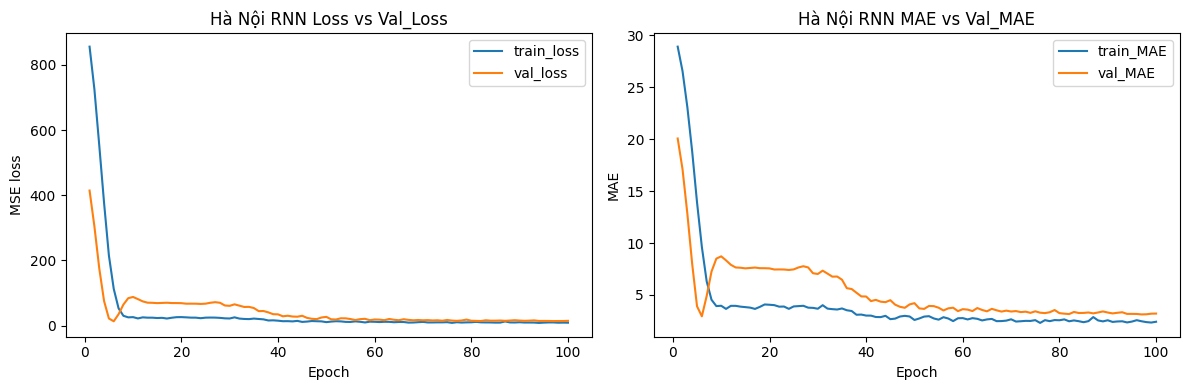

### Hà Nội - LSTM ###


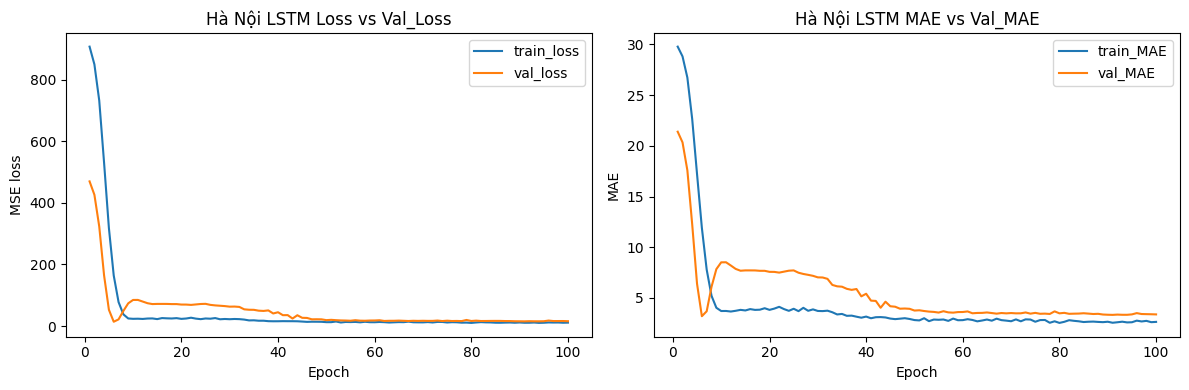

### Đà Nẵng - RNN ###


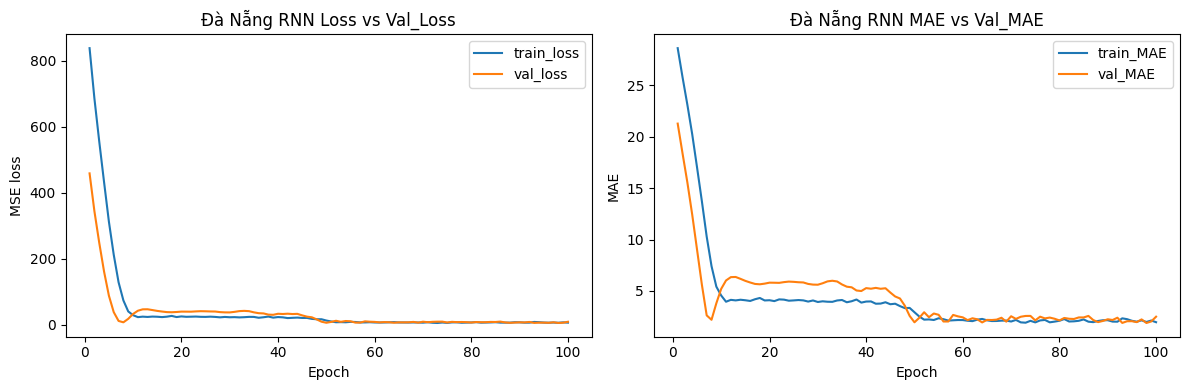

### Đà Nẵng - LSTM ###


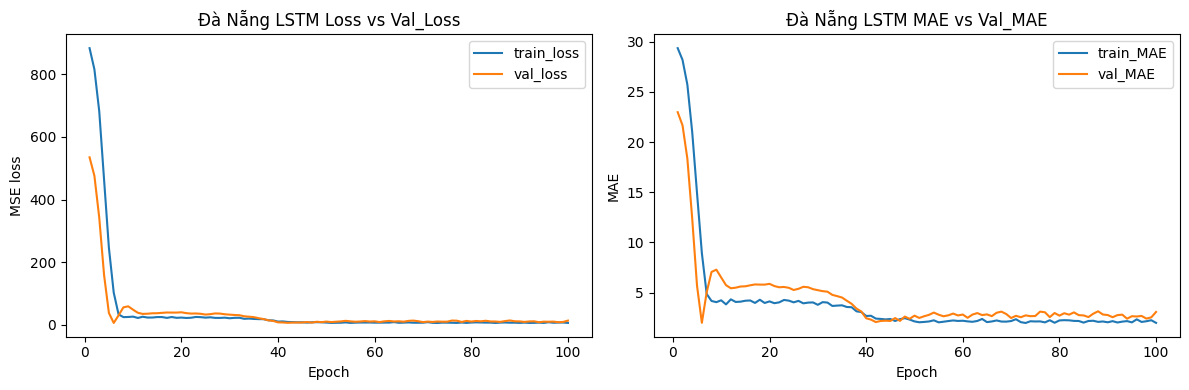

### TP. Hồ Chí Minh - RNN ###


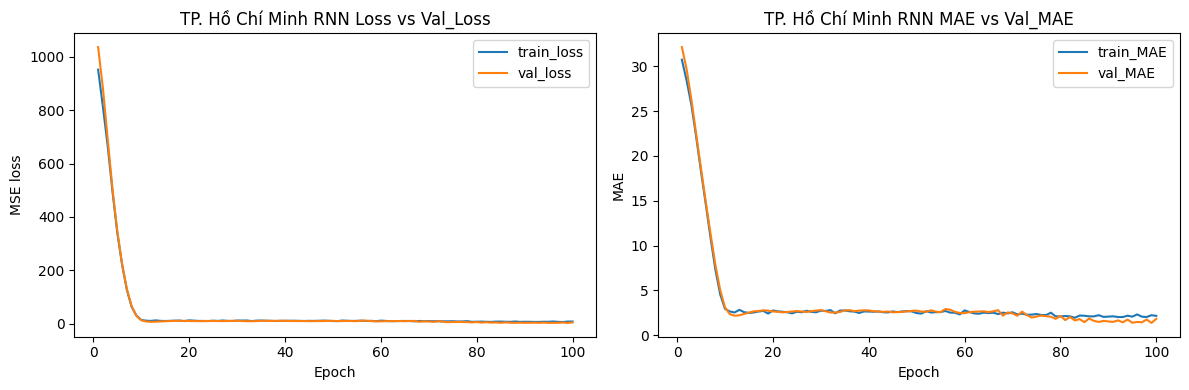

### TP. Hồ Chí Minh - LSTM ###


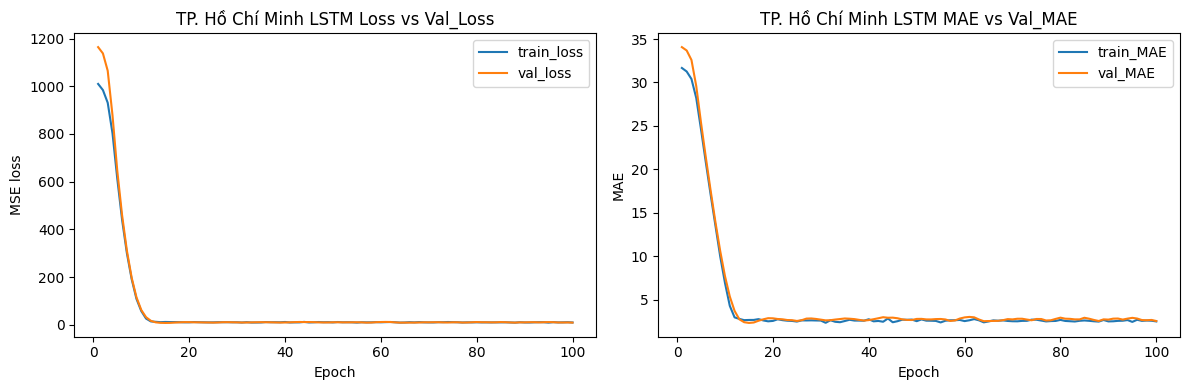

In [10]:
# Cell #7: Plot training curves
#B22DCCN476
# -----------------------------

def plot_history(history_dict, title_prefix=""):
    # history_dict = results[city]["rnn"]["history"] ...
    loss      = history_dict["loss"]
    val_loss  = history_dict["val_loss"]
    mae       = history_dict["mae"]
    val_mae   = history_dict["val_mae"]

    epochs_range = range(1, len(loss)+1)

    plt.figure(figsize=(12,4))

    # Subplot 1: Loss
    plt.subplot(1,2,1)
    plt.plot(epochs_range, loss, label="train_loss")
    plt.plot(epochs_range, val_loss, label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title(f"{title_prefix} Loss vs Val_Loss")
    plt.legend()

    # Subplot 2: MAE
    plt.subplot(1,2,2)
    plt.plot(epochs_range, mae, label="train_MAE")
    plt.plot(epochs_range, val_mae, label="val_MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.title(f"{title_prefix} MAE vs Val_MAE")
    plt.legend()

    plt.tight_layout()
    plt.show()


for city in CITIES:
    print(f"### {city} - RNN ###")
    plot_history(results[city]["rnn"]["history"], title_prefix=f"{city} RNN")
    print(f"### {city} - LSTM ###")
    plot_history(results[city]["lstm"]["history"], title_prefix=f"{city} LSTM")


📋 Bảng tổng hợp chỉ số trên tập Test:


,City,Model,MAE,MSE,RMSE
0,Hà Nội,RNN,3.191,14.300,3.781
1,Hà Nội,LSTM,4.246,25.222,5.022
2,Đà Nẵng,RNN,2.217,8.382,2.895
3,Đà Nẵng,LSTM,2.773,12.809,3.579
4,TP. Hồ Chí Minh,RNN,2.231,6.523,2.554
5,TP. Hồ Chí Minh,LSTM,3.691,16.003,4.000


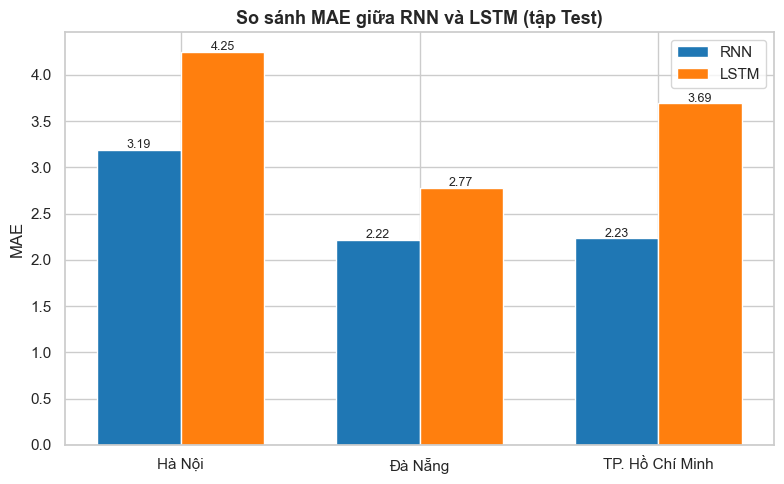

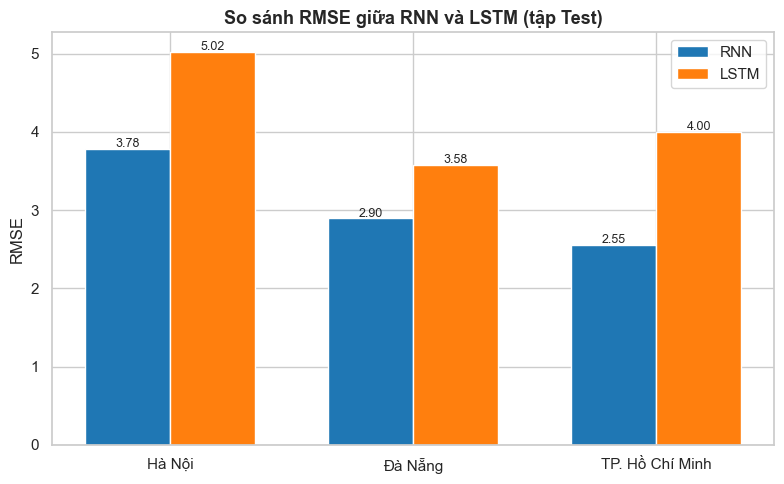

In [11]:
# Cell #8 (FINAL): Bảng và biểu đồ so sánh chỉ số cuối cùng
# Đỗ Ngọc Lâm – B22DCCN476
# ----------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==== Tạo bảng kết quả ====
summary_rows = []
for city in CITIES:
    rnn_res  = results[city]["rnn"]
    lstm_res = results[city]["lstm"]
    summary_rows.append({
        "City": city,
        "Model": "RNN",
        "MAE":  rnn_res["mae"],
        "MSE":  rnn_res["mse"],
        "RMSE": rnn_res["rmse"],
    })
    summary_rows.append({
        "City": city,
        "Model": "LSTM",
        "MAE":  lstm_res["mae"],
        "MSE":  lstm_res["mse"],
        "RMSE": lstm_res["rmse"],
    })

df_summary = pd.DataFrame(summary_rows)
print("📋 Bảng tổng hợp chỉ số trên tập Test:")
display(df_summary.round(3))

# ==== Vẽ biểu đồ cột nhóm đẹp ====
sns.set(style="whitegrid", font="Arial")

metrics_to_plot = ["MAE", "RMSE"]
colors = {"RNN": "#1f77b4", "LSTM": "#ff7f0e"}

for metric in metrics_to_plot:
    plt.figure(figsize=(8,5))
    bar_width = 0.35
    x = np.arange(len(CITIES))

    rnn_vals = df_summary[df_summary["Model"]=="RNN"][metric].values
    lstm_vals = df_summary[df_summary["Model"]=="LSTM"][metric].values

    plt.bar(x - bar_width/2, rnn_vals, width=bar_width, color=colors["RNN"], label="RNN")
    plt.bar(x + bar_width/2, lstm_vals, width=bar_width, color=colors["LSTM"], label="LSTM")

    # Hiển thị giá trị trên đầu cột
    for i in range(len(CITIES)):
        plt.text(x[i]-bar_width/2, rnn_vals[i]+0.02, f"{rnn_vals[i]:.2f}", ha="center", fontsize=9)
        plt.text(x[i]+bar_width/2, lstm_vals[i]+0.02, f"{lstm_vals[i]:.2f}", ha="center", fontsize=9)

    plt.xticks(x, CITIES, fontsize=11)
    plt.ylabel(metric)
    plt.title(f"So sánh {metric} giữa RNN và LSTM (tập Test)", fontsize=13, weight='bold')
    plt.legend()
    plt.tight_layout()
    plt.show()


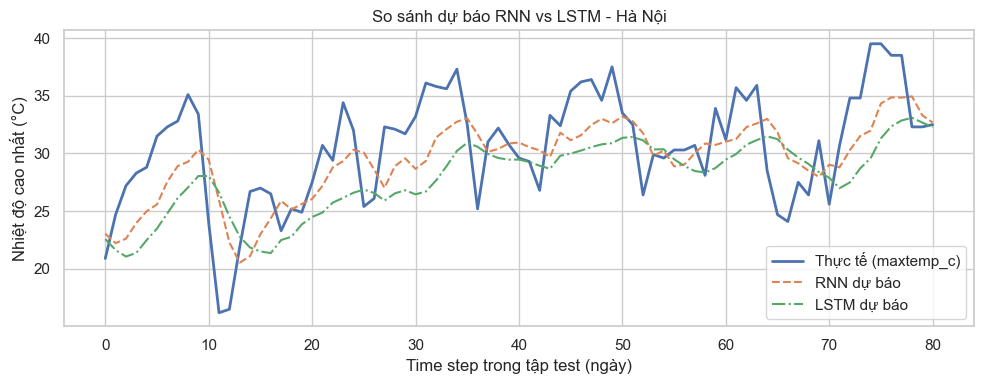

=== Hà Nội ===
RNN  -> MAE = 3.191, MSE = 14.300, RMSE = 3.781
LSTM -> MAE = 4.246, MSE = 25.222, RMSE = 5.022
--------------------------------------------------------------------------------


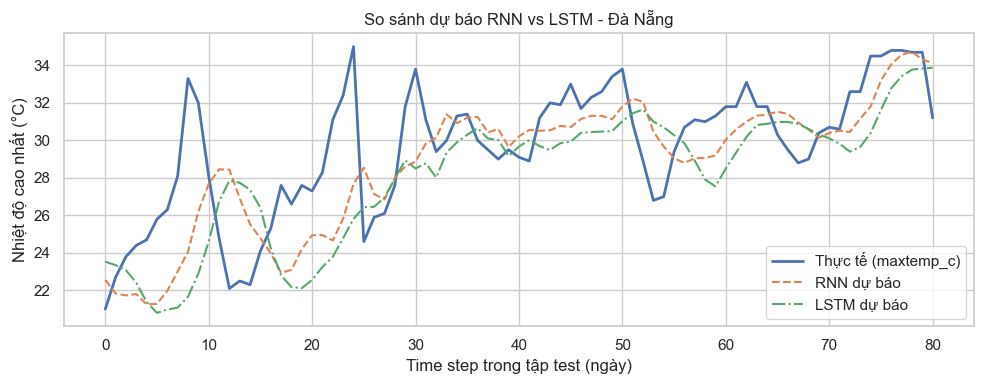

=== Đà Nẵng ===
RNN  -> MAE = 2.217, MSE = 8.382, RMSE = 2.895
LSTM -> MAE = 2.773, MSE = 12.809, RMSE = 3.579
--------------------------------------------------------------------------------


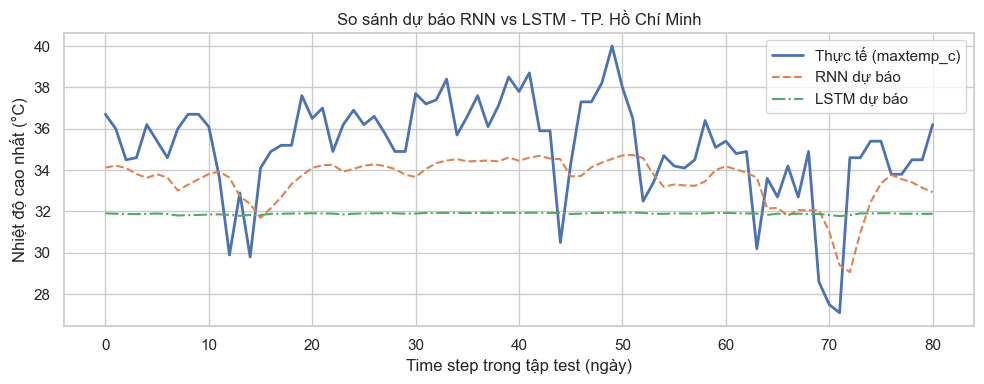

=== TP. Hồ Chí Minh ===
RNN  -> MAE = 2.231, MSE = 6.523, RMSE = 2.554
LSTM -> MAE = 3.691, MSE = 16.003, RMSE = 4.000
--------------------------------------------------------------------------------


In [12]:
# Cell #9 (UPDATED): So sánh dự báo RNN vs LSTM cho cả 3 thành phố
# Đỗ Ngọc Lâm – B22DCCN476
# -------------------------------------------------------------

for city in CITIES:
    rnn_res  = results[city]["rnn"]
    lstm_res = results[city]["lstm"]

    y_test = rnn_res["y_test"]
    y_pred_rnn  = rnn_res["y_pred"]
    y_pred_lstm = lstm_res["y_pred"]

    plt.figure(figsize=(10, 4))
    plt.plot(y_test, label="Thực tế (maxtemp_c)", linewidth=2)
    plt.plot(y_pred_rnn, label="RNN dự báo", linestyle="--")
    plt.plot(y_pred_lstm, label="LSTM dự báo", linestyle="-.")
    plt.xlabel("Time step trong tập test (ngày)")
    plt.ylabel("Nhiệt độ cao nhất (°C)")
    plt.title(f"So sánh dự báo RNN vs LSTM - {city}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"=== {city} ===")
    print(f"RNN  -> MAE = {rnn_res['mae']:.3f}, MSE = {rnn_res['mse']:.3f}, RMSE = {rnn_res['rmse']:.3f}")
    print(f"LSTM -> MAE = {lstm_res['mae']:.3f}, MSE = {lstm_res['mse']:.3f}, RMSE = {lstm_res['rmse']:.3f}")
    print("-" * 80)
